In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import NonlocalSolverMomentumAdam
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# CONTINUOUS ADAM

In [3]:
def dL_wrapper(theta):
    return dL_rosenbrock_1d(theta, (c_value,))

In [4]:
print("Solving theta...")
optimizer_theta = NonlocalSolverMomentumAdam(
    dL=dL_wrapper,
    t_span=(lr, lr*epochs),
    y0=[initial_theta, initial_velocity],
    alpha=lr,
    betas=(beta1, beta2),
    eps_base=epsilon,
    verbose=False,
    quad_order=quad_order
)
t, y = optimizer_theta.solve()

if y.shape[1] == 2:
    # Equation of firs orden: y contains directly theta and dtheta/dt
    theta_history = y[:,0]
    theta_dot_history = y[:,1]
    theta_ddot_history = None

    final_state = theta_history[-1]
    final_velocity = theta_dot_history[-1]
    
    print(f"\nFinal value of theta: {float(final_state):.6e}")
    print(f"Final velocity: {float(final_velocity):.6e}")

elif y.shape[1] == 3:
    # Second order equation: y has columns [theta, theta_dot, theta_ddot]
    theta_history = y[:, 0]
    theta_dot_history = y[:, 1]
    theta_ddot_history = y[:, 2]

    final_state = theta_history[-1]
    final_velocity = theta_dot_history[-1]
    final_acceleration = theta_ddot_history[-1]

    print(f"\nFinal value of theta: {float(final_state):.6e}")
    print(f"Final velocity: {float(final_velocity):.6e}")
    print(f"Final acceleration: {float(final_acceleration):.6e}")  

print(f"Final time: {t[-1]}")
print(f"Number of steps: {len(t)}")

Solving theta...
Iter   20 │ err=3.264325e-03 │ smooth=0.5010

Convergence achieved!
Final iteration: 30
Final error: 5.283564e-06
Final smoothing: 0.5010


Final value of theta: -8.535615e-01
Final velocity: 9.388591e-04
Final acceleration: -4.774145e-03
Final time: 1.1999799999999998
Number of steps: 59995


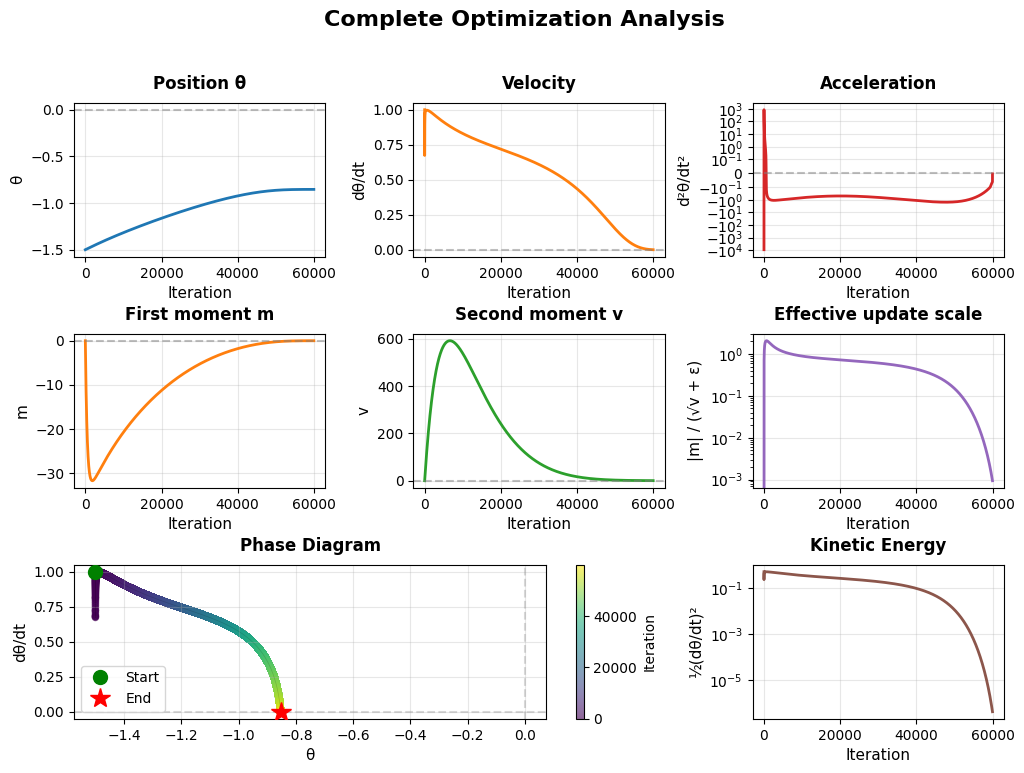

In [5]:
# Crear el plotter y visualizar
plotter = AdamPlotter(
    theta_history=theta_history,
    m_history=optimizer_theta._last_m[:, 1],
    v_history=optimizer_theta._last_v[:, 1],
    theta_dot_history=theta_dot_history,     
    theta_ddot_history=theta_ddot_history    
)

# Plotear todo
plotter.plot('all')
plt.show()

# Save Results

In [6]:
# Create DataFrame
df_continuous = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': theta_dot_history,
    'theta_ddot_history': theta_ddot_history,
    'm_history': optimizer_theta._last_m[:, 1],
    'v_history': optimizer_theta._last_v[:, 1]
})

# Save to CSV
df_continuous.to_csv(f'results_2nd_order/second_order_c_{c_value}_initial_theta_{initial_theta}_initial_velocity_{initial_velocity}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results_2nd_order/second_order_c_{c_value}_initial_theta_{initial_theta}_initial_velocity_{initial_velocity}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_continuous)}")

Results saved in 'results_2nd_order/second_order_c_4.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.0001_beta1_0.99_beta2_0.999.csv'
Total rows: 59995
